In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11155153.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/17555081.pdf
/kaggl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using Device: cuda
CSV Exists: True
PDF Base Exists: True
Total resumes loaded: 2483


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 1/8, Loss: 122.9759
Epoch 2/8, Loss: 63.6219
Epoch 3/8, Loss: 48.6892
Epoch 4/8, Loss: 39.2505
Epoch 5/8, Loss: 30.5616
Epoch 6/8, Loss: 26.7399
Epoch 7/8, Loss: 25.3727
Epoch 8/8, Loss: 18.3069

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.95      0.83      0.89        24
              ADVOCATE       0.67      0.75      0.71        24
           AGRICULTURE       0.67      0.31      0.42        13
               APPAREL       0.38      0.32      0.34        19
                  ARTS       0.09      0.05      0.06        21
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.46      0.46      0.46        24
               BANKING       0.63      0.52      0.57        23
                   BPO       0.29      0.50      0.36         4
  BUSINESS-DEVELOPMENT       1.00      0.54      0.70        24
                  CHEF       0.91      0.88      0.89        24
      

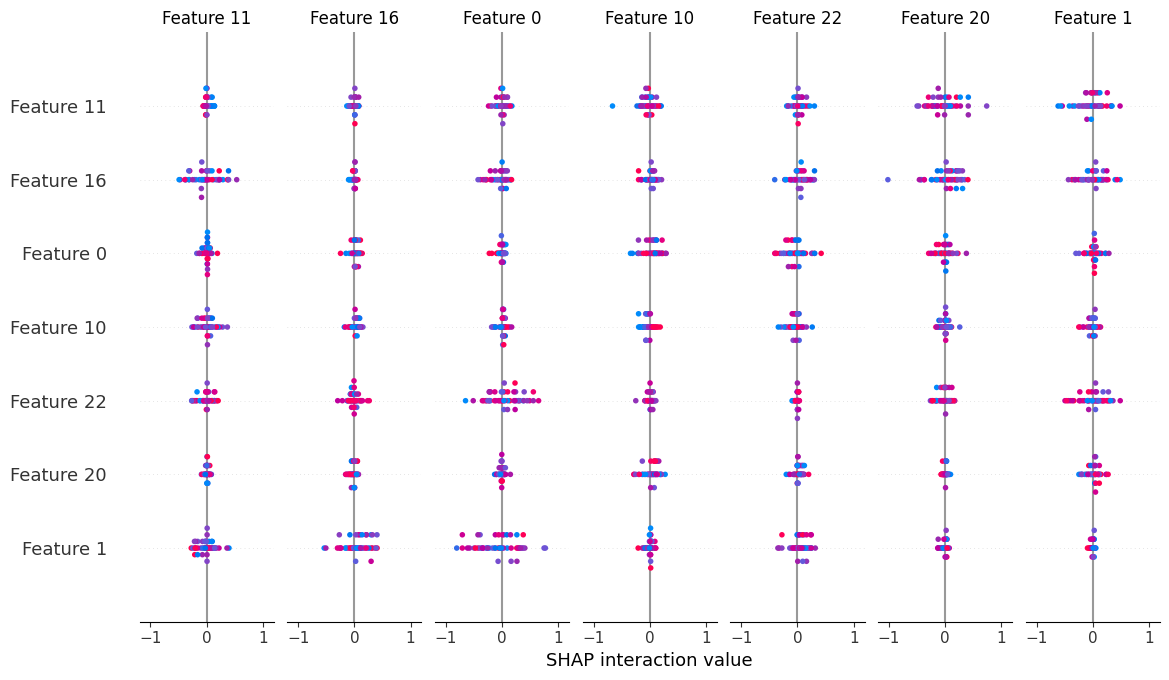

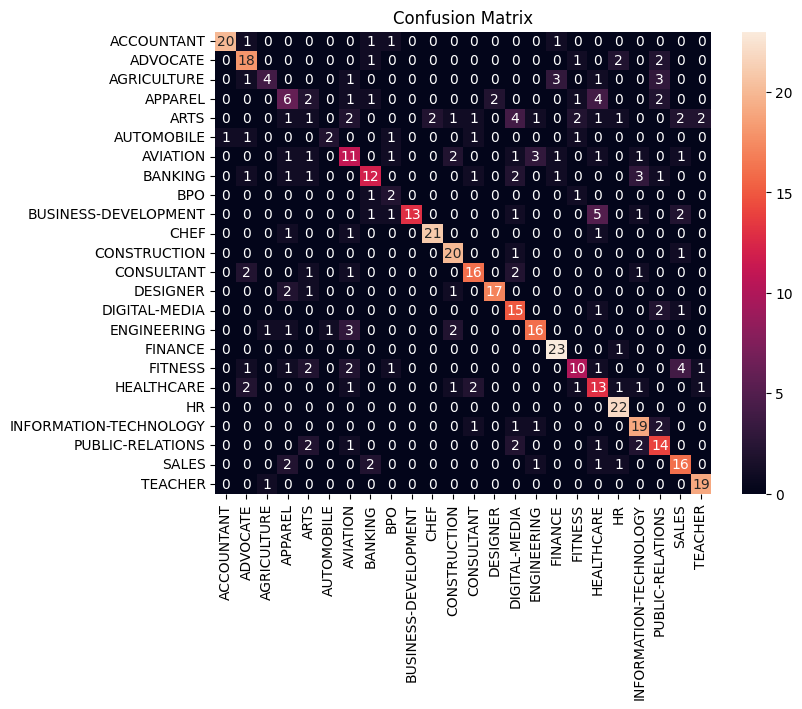


🚀 SYSTEM COMPLETE WITH UPDATED PATHS!


In [2]:
# ==========================================================
# 🚀 DEEP LEARNING + XAI SMART RECRUITMENT SYSTEM (KAGGLE)
# ==========================================================

# ================================
# 1️⃣ INSTALL REQUIRED PACKAGES
# ================================
!pip install --quiet pdfplumber sentence-transformers faiss-cpu nltk spacy shap lime
!python -m spacy download en_core_web_sm

# ================================
# 2️⃣ IMPORT LIBRARIES
# ================================
import os
import numpy as np
import pandas as pd
import pdfplumber
import nltk
import torch
import faiss
import spacy
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
from lime.lime_tabular import LimeTabularExplainer

nltk.download('stopwords')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ================================
# 3️⃣ UPDATED DATA PATHS
# ================================

CSV_PATH = "/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv"
BASE_PATH = "/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data"

print("CSV Exists:", os.path.exists(CSV_PATH))
print("PDF Base Exists:", os.path.exists(BASE_PATH))

def extract_pdf_text(pdf_path):
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + " "
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
    return text

resume_texts = []
resume_labels = []

for category in os.listdir(BASE_PATH):
    category_path = os.path.join(BASE_PATH, category)
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            if file.endswith(".pdf"):
                pdf_path = os.path.join(category_path, file)
                text = extract_pdf_text(pdf_path)
                if len(text) > 50:
                    resume_texts.append(text)
                    resume_labels.append(category)

print("Total resumes loaded:", len(resume_texts))

# ================================
# 4️⃣ LABEL ENCODING
# ================================
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(resume_labels)

# ================================
# 5️⃣ SBERT EMBEDDINGS
# ================================
model_sbert = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
resume_embeddings = model_sbert.encode(
    resume_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

# ================================
# 6️⃣ FAISS INDEX
# ================================
dimension = resume_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(resume_embeddings)

# ================================
# 7️⃣ DEEP LEARNING CLASSIFIER
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    resume_embeddings,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                         batch_size=32)

class ResumeClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model_dl = ResumeClassifier(dimension, len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dl.parameters(), lr=1e-3)

EPOCHS = 8

for epoch in range(EPOCHS):
    model_dl.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model_dl(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}")

# Evaluation
model_dl.eval()
preds_all, labels_all = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_dl(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(yb.numpy())

print("\nClassification Report:")
print(classification_report(labels_all, preds_all, target_names=label_encoder.classes_))
print("Accuracy:", round(accuracy_score(labels_all, preds_all), 3))

# ================================
# 8️⃣ JOB MATCHING
# ================================
job_description = """
We are looking for a UI/UX Designer with experience in Figma,
Adobe XD, wireframing, prototyping, and responsive web design.
Strong communication skills required.
"""

job_embedding = model_sbert.encode([job_description], convert_to_numpy=True)

TOP_K = 5
distances, indices = index.search(job_embedding, TOP_K)

print("\nTop Matching Candidates:")
for rank, idx in enumerate(indices[0]):
    print(f"Rank {rank+1} | {resume_labels[idx]} | Score: {round(1/(1+distances[0][rank]),3)}")

# ================================
# 9️⃣ ATTENTION MATCHING
# ================================
class AttentionMatcher(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, dim)
    def forward(self, resume_emb, job_emb):
        weights = torch.softmax(self.attn(job_emb), dim=1)
        score = torch.sum(resume_emb * weights, dim=1)
        return score

attention_model = AttentionMatcher(dimension).to(device)
resume_tensor = torch.tensor(resume_embeddings, dtype=torch.float32).to(device)
job_tensor = torch.tensor(job_embedding, dtype=torch.float32).to(device)

attention_scores = attention_model(
    resume_tensor,
    job_tensor.repeat(len(resume_embeddings),1)
)

top_attention = torch.topk(attention_scores, 5).indices.cpu().numpy()

print("\nAttention-Based Top Candidates:")
for rank, idx in enumerate(top_attention):
    print(f"Rank {rank+1} | {resume_labels[idx]}")

# ================================
# 🔟 HIRE PROBABILITY
# ================================
def hire_probability(idx):
    similarity = cosine_similarity(
        resume_embeddings[idx].reshape(1,-1),
        job_embedding
    )[0][0]
    return round(0.7 * similarity, 3)

print("\nHire Probability:")
for rank, idx in enumerate(indices[0]):
    print(f"Rank {rank+1} | {resume_labels[idx]} | Probability: {hire_probability(idx)}")

# ================================
# 1️⃣1️⃣ SHAP EXPLAINABILITY
# ================================
background = torch.tensor(X_train[:100], dtype=torch.float32).to(device)
explainer = shap.DeepExplainer(model_dl, background)

sample = torch.tensor(X_test[:50], dtype=torch.float32).to(device)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, X_test[:50], show=False)

# ================================
# 1️⃣2️⃣ LIME EXPLAINABILITY
# ================================
explainer_lime = LimeTabularExplainer(
    training_data=X_train,
    mode="classification",
    class_names=label_encoder.classes_,
    feature_names=[f"emb_{i}" for i in range(X_train.shape[1])]
)

def predict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        return torch.softmax(model_dl(x_tensor), dim=1).cpu().numpy()

exp = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)

# ================================
# 1️⃣3️⃣ CONFUSION MATRIX
# ================================
cm = confusion_matrix(labels_all, preds_all)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.show()

print("\n🚀 SYSTEM COMPLETE WITH UPDATED PATHS!")

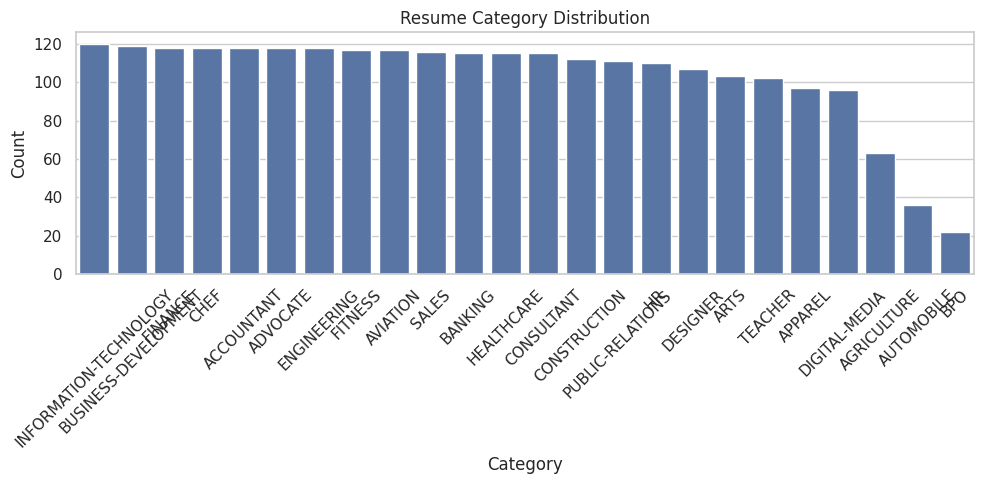

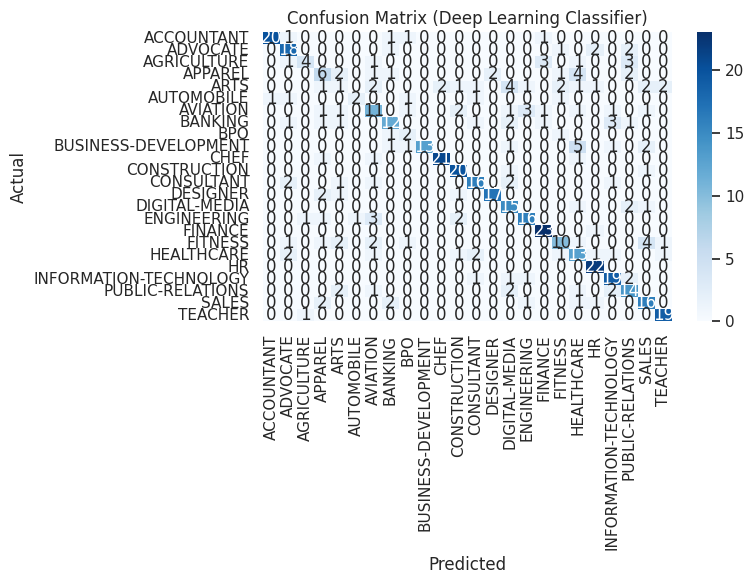

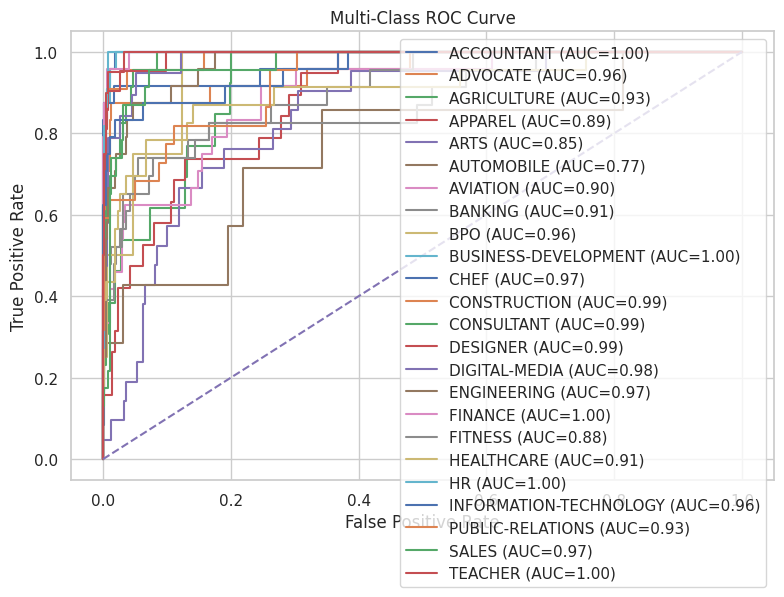

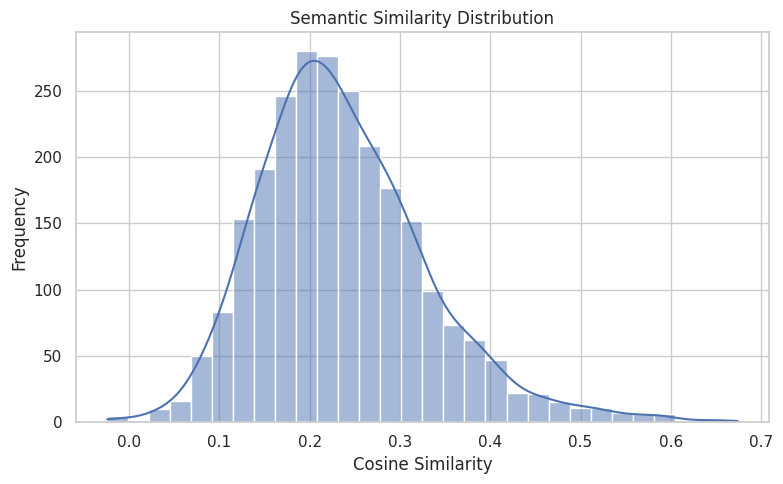

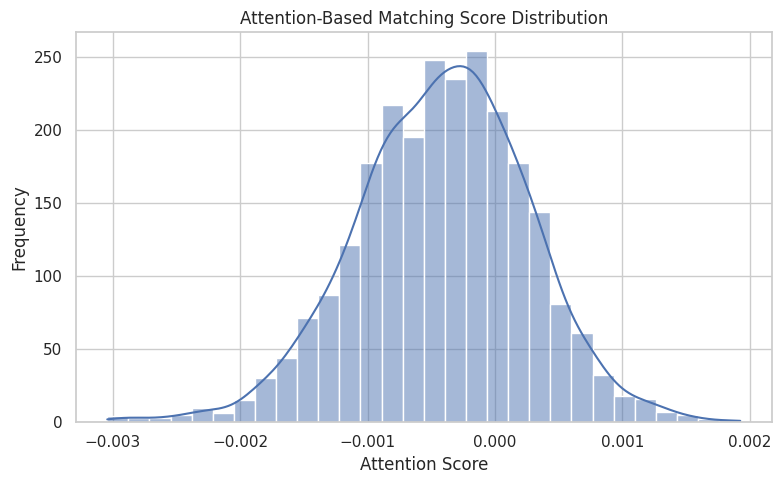

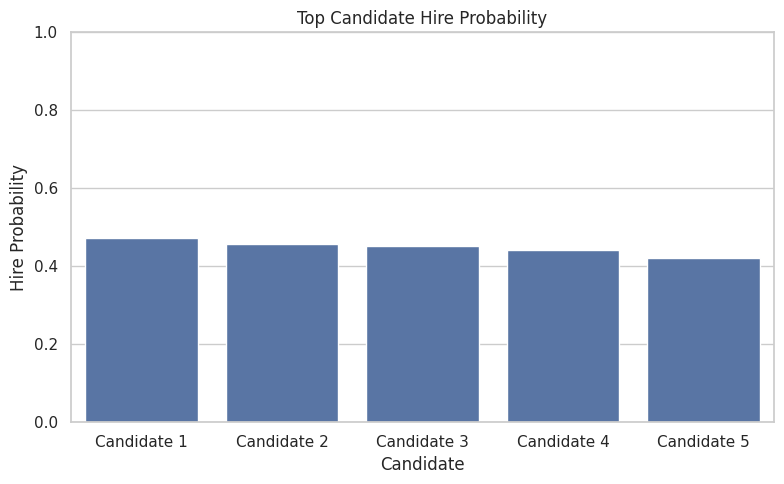

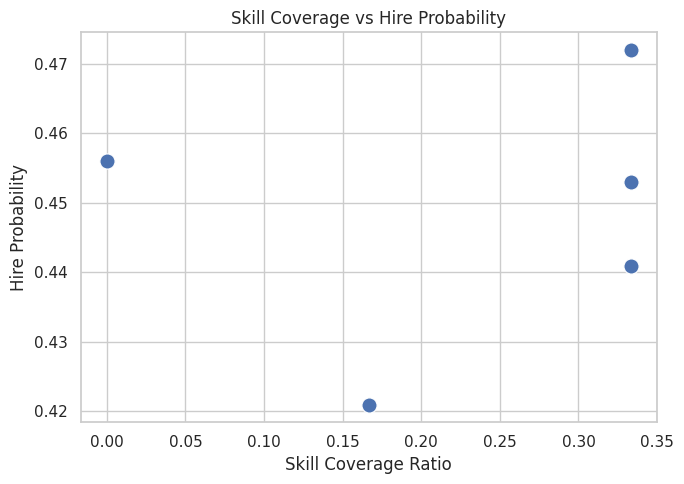

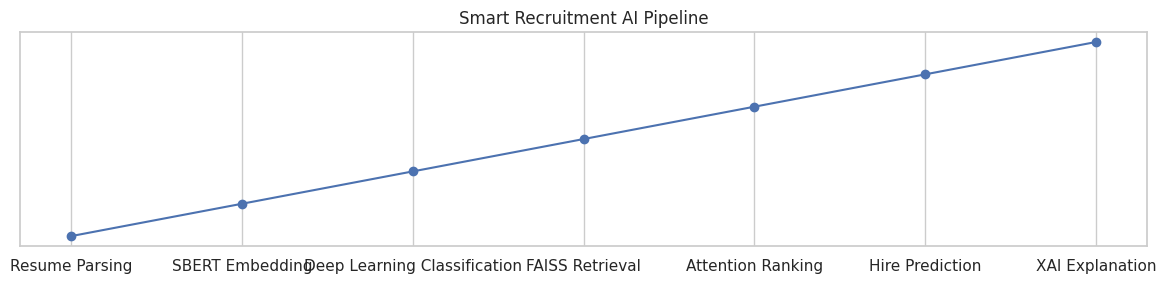

📊 All Performance Visualizations Generated Successfully!


In [3]:
# ==========================================================
# 📊 PERFORMANCE VISUALIZATION BLOCK
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics.pairwise import cosine_similarity

sns.set(style="whitegrid")

# ======================================
# 1️⃣ Resume Category Distribution
# ======================================
plt.figure(figsize=(10,5))
sns.countplot(x=resume_labels,
              order=pd.Series(resume_labels).value_counts().index)
plt.xticks(rotation=45)
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ======================================
# 2️⃣ Confusion Matrix
# ======================================
cm = confusion_matrix(labels_all, preds_all)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix (Deep Learning Classifier)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ======================================
# 3️⃣ ROC Curve (Multi-Class)
# ======================================
y_test_bin = label_binarize(labels_all,
                            classes=np.arange(len(label_encoder.classes_)))

preds_prob = []
model_dl.eval()
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = torch.softmax(model_dl(xb), dim=1)
        preds_prob.extend(outputs.cpu().numpy())

preds_prob = np.array(preds_prob)

plt.figure(figsize=(8,6))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


# ======================================
# 4️⃣ Semantic Similarity Distribution
# ======================================
similarity_scores = []

for i in range(len(resume_embeddings)):
    sim = cosine_similarity(
        resume_embeddings[i].reshape(1, -1),
        job_embedding
    )[0][0]
    similarity_scores.append(sim)

plt.figure(figsize=(8,5))
sns.histplot(similarity_scores, bins=30, kde=True)
plt.title("Semantic Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ======================================
# 5️⃣ Attention Score Distribution
# ======================================
att_scores = attention_scores.detach().cpu().numpy()

plt.figure(figsize=(8,5))
sns.histplot(att_scores, bins=30, kde=True)
plt.title("Attention-Based Matching Score Distribution")
plt.xlabel("Attention Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ======================================
# 6️⃣ Hire Probability Ranking
# ======================================
candidate_names = [f"Candidate {i+1}" for i in range(len(indices[0]))]
candidate_probs = [hire_probability(i) for i in indices[0]]

plt.figure(figsize=(8,5))
sns.barplot(x=candidate_names, y=candidate_probs)
plt.title("Top Candidate Hire Probability")
plt.xlabel("Candidate")
plt.ylabel("Hire Probability")
plt.ylim(0,1)
plt.tight_layout()
plt.show()


# ======================================
# 7️⃣ Skill Coverage vs Hire Probability
# ======================================
skill_coverages = []
hire_probs = []

job_skills = ["figma","adobe","wireframing",
              "prototyping","responsive","communication"]

nlp = spacy.load("en_core_web_sm")

def extract_skills(text):
    doc = nlp(text.lower())
    skills = set()
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"] and len(token.text) > 2:
            skills.add(token.text)
    return list(skills)

for i in indices[0]:
    candidate_skills = extract_skills(resume_texts[i])
    coverage = len(set(candidate_skills) & set(job_skills)) / len(job_skills)
    skill_coverages.append(coverage)
    hire_probs.append(hire_probability(i))

plt.figure(figsize=(7,5))
sns.scatterplot(x=skill_coverages,
                y=hire_probs,
                s=120)
plt.title("Skill Coverage vs Hire Probability")
plt.xlabel("Skill Coverage Ratio")
plt.ylabel("Hire Probability")
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================================
# 8️⃣ Pipeline Flow Visualization
# ======================================
stages = [
    "Resume Parsing",
    "SBERT Embedding",
    "Deep Learning Classification",
    "FAISS Retrieval",
    "Attention Ranking",
    "Hire Prediction",
    "XAI Explanation"
]

plt.figure(figsize=(12,3))
plt.plot(stages, range(len(stages)), marker="o")
plt.yticks([])
plt.title("Smart Recruitment AI Pipeline")
plt.grid(True)
plt.tight_layout()
plt.show()

print("📊 All Performance Visualizations Generated Successfully!")